In [45]:
!pip install tensorflow
import numpy as pd
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense,SimpleRNN,Bidirectional

In [46]:
max_features = 10000  #vocab size
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=max_features)

print(f"traing data shape:{X_train.shape} and traning lable shape:{y_train.shape}")
print(f"testing data shape:{X_test.shape} and testing lable shape:{y_test.shape}")

traing data shape:(25000,) and traning lable shape:(25000,)
testing data shape:(25000,) and testing lable shape:(25000,)


In [47]:
# Load the IMDB dataset word index
word_index = imdb.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}

In [48]:
max_len = 500
X_train = sequence.pad_sequences(X_train, maxlen=max_len)
X_test = sequence.pad_sequences(X_test, maxlen=max_len)

In [49]:
X_train

array([[   0,    0,    0, ...,   19,  178,   32],
       [   0,    0,    0, ...,   16,  145,   95],
       [   0,    0,    0, ...,    7,  129,  113],
       ...,
       [   0,    0,    0, ...,    4, 3586,    2],
       [   0,    0,    0, ...,   12,    9,   23],
       [   0,    0,    0, ...,  204,  131,    9]], dtype=int32)

In [50]:
model = Sequential()
model.add(Embedding(max_features,128))
model.add(SimpleRNN(128,activation='tanh', dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(1,activation='sigmoid') )
model.build(input_shape=(None, max_len))

In [ ]:
model.summary()

In [56]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [58]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [59]:


hist = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=20,
    validation_split=0.2,
    # callbacks=[early_stopping]
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 76ms/step - accuracy: 0.7035 - loss: 0.5600 - val_accuracy: 0.6292 - val_loss: 0.6565
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 76ms/step - accuracy: 0.7058 - loss: 0.5428 - val_accuracy: 0.6358 - val_loss: 0.6635
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 76ms/step - accuracy: 0.7371 - loss: 0.4956 - val_accuracy: 0.6490 - val_loss: 0.6787
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 77ms/step - accuracy: 0.7643 - loss: 0.4650 - val_accuracy: 0.6520 - val_loss: 0.6912
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accuracy: 0.7970 - loss: 0.4250 - val_accuracy: 0.6768 - val_loss: 0.6848
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 76ms/step - accuracy: 0.8173 - loss: 0.3914 - val_accuracy: 0.6958 - val_loss: 0.7073
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accuracy: 0.8389 - loss: 0.3640 - val_accuracy: 0.6366 - val_loss: 0.7625
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 76ms/step - accuracy: 0.8297 - loss: 0.3669 - 

In [64]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.6924 - loss: 0.9884
Test Loss: 0.9861
Test Accuracy: 0.6945


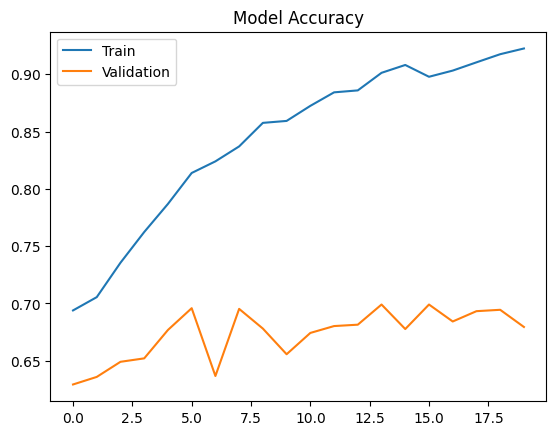

In [65]:
import matplotlib.pyplot as plt

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

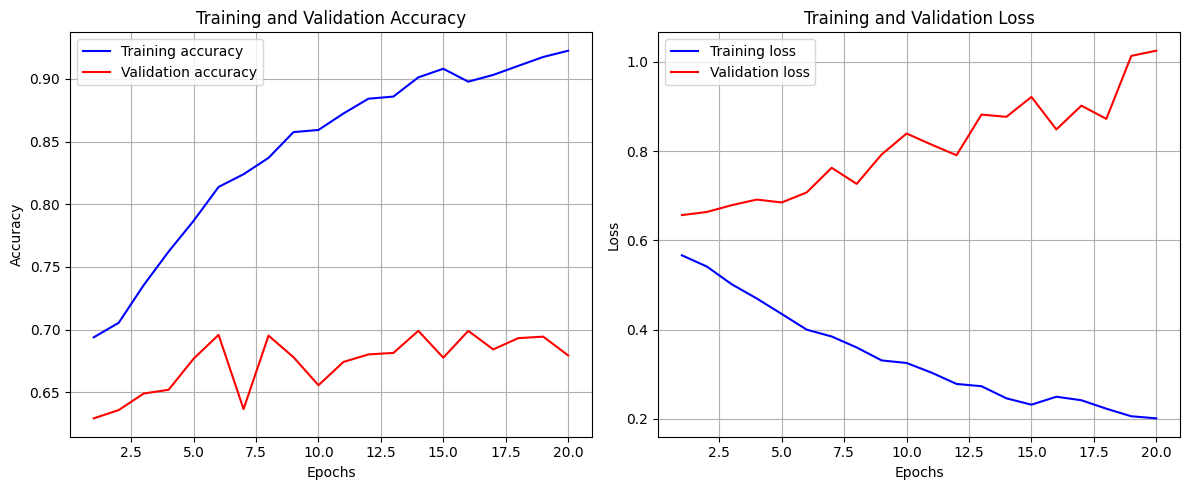

In [66]:
import matplotlib.pyplot as plt

# Get training and validation metrics from the history object
acc = hist.history['accuracy']
val_acc = hist.history['val_accuracy']
loss = hist.history['loss']
val_loss = hist.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Plot training and validation accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [67]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,939,077 (15.03 MB)

 Trainable params: 1,313,025 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,626,052 (10.02 MB)

In [68]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [63]:
model.save("Simple_Rnn_imdb2.h5")

In [60]:
def decode_review(encoded_review):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in encoded_review])

# Function to preprocess user input
def preprocess_text(text):
    words = text.lower().split()
    encoded_review = [word_index.get(word, 2) + 3 for word in words]
    padded_review = sequence.pad_sequences([encoded_review], maxlen=500)
    return padded_review

In [61]:

def predict_sentiment(review):
    preprocessed_input=preprocess_text(review)

    prediction=model.predict(preprocessed_input)

    sentiment = 'Positive' if prediction[0][0] > 0.5 else 'Negative'

    return sentiment, prediction[0][0]


In [62]:
example_review = "This movie was fantastic! The acting was great and the plot was thrilling."

sentiment,score=predict_sentiment(example_review)

print(f'Review: {example_review}')
print(f'Sentiment: {sentiment}')
print(f'Prediction Score: {score}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
Review: This movie was fantastic! The acting was great and the plot was thrilling.
Sentiment: Positive
Prediction Score: 0.8120962977409363
